# Phase 3: Feature Engineering

Objective:
To generate predictive features from historical stock data
using technical indicators and statistical transformations.

Features to be created:
- RSI (Momentum)
- MACD (Trend)
- SMA (Moving Averages)
- Volatility
- Volume Ratio
- Returns-based features


In [1]:
import pandas as pd
import ta

# Load dataset
df = pd.read_csv("../data/raw/RELIANCE.NS.csv", index_col=0)
df.index = pd.to_datetime(df.index, errors="coerce")

# Remove invalid rows
df = df[~df.index.isna()]

df.head()

C:\Users\Dell\AppData\Local\Temp\ipykernel_13524\735737068.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df.index = pd.to_datetime(df.index, errors="coerce")


,Close,High,Low,Open,Volume
Price,,,,,
2021-03-02,954.9262084960938,965.8085514456496,947.2632505723379,962.1811437745009,17150760
2021-03-03,998.5009765625,1006.572077071357,955.4703590572257,961.750393670414,31924461
2021-03-04,986.5984497070312,992.9918242849485,978.3686732860034,988.4801874020635,21435754
2021-03-05,987.8906860351562,1002.9673152550806,976.260181188279,977.5978286714029,25511666
2021-03-08,993.5133056640625,1012.0132716669716,983.039044773577,983.2657240329895,19506841


In [4]:
df.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')

In [5]:
# Convert all numeric columns safely
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Drop missing rows
df = df.dropna()

df.dtypes

Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
dtype: object

In [6]:
df["RSI"] = ta.momentum.RSIIndicator(close=df["Close"], window=14).rsi()

df[["Close", "RSI"]].head()

,Close,RSI
Price,,
2021-03-02,954.926208,NaN
2021-03-03,998.500977,NaN
2021-03-04,986.598450,NaN
2021-03-05,987.890686,NaN
2021-03-08,993.513306,NaN


In [7]:
df = df.dropna()

df.head()

,Close,High,Low,Open,Volume,RSI
Price,,,,,,
2021-03-22,935.156616,940.416414,921.916449,939.056159,18572478,40.733968
2021-03-23,946.537720,956.603897,932.254649,934.952552,17421165,45.916390
2021-03-24,928.309814,943.023636,925.181161,943.023636,16822814,39.898785
2021-03-25,902.985596,931.347725,900.060954,931.347725,22001648,33.357873
2021-03-26,904.436646,913.074504,894.937286,912.303675,20180202,34.025274


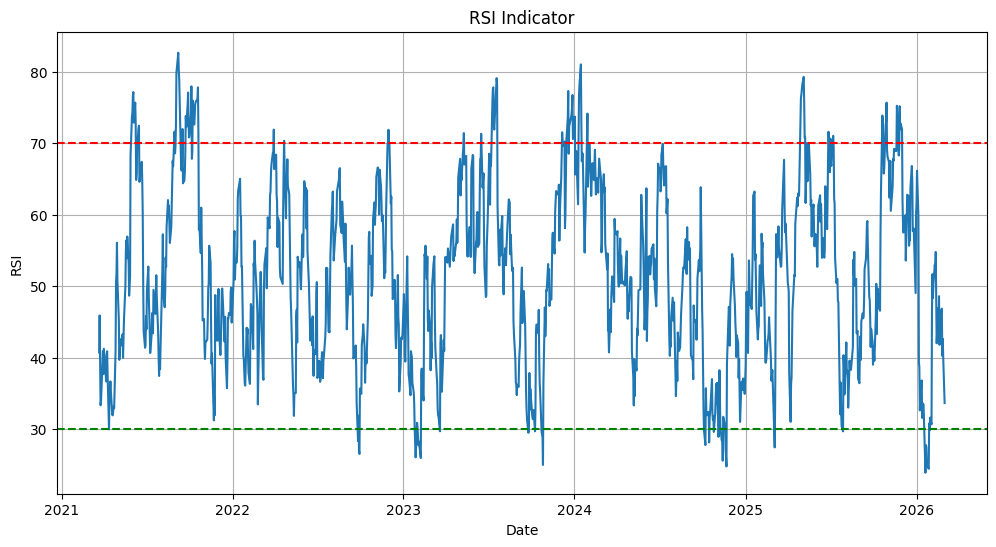

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(df.index, df["RSI"])
plt.axhline(70, color='red', linestyle='--')
plt.axhline(30, color='green', linestyle='--')
plt.title("RSI Indicator")
plt.xlabel("Date")
plt.ylabel("RSI")
plt.grid(True)
plt.show()

## RSI Interpretation

- RSI > 70 → Overbought (potential downward correction)
- RSI < 30 → Oversold (potential upward correction)

RSI captures short-term momentum and is widely used
in quantitative trading strategies.

In [9]:
# Create MACD indicator
macd = ta.trend.MACD(close=df["Close"])

df["MACD"] = macd.macd()
df["MACD_Signal"] = macd.macd_signal()
df["MACD_Hist"] = macd.macd_diff()

df[["Close", "MACD", "MACD_Signal"]].head()

,Close,MACD,MACD_Signal
Price,,,
2021-03-22,935.156616,NaN,NaN
2021-03-23,946.537720,NaN,NaN
2021-03-24,928.309814,NaN,NaN
2021-03-25,902.985596,NaN,NaN
2021-03-26,904.436646,NaN,NaN


In [10]:
df = df.dropna()

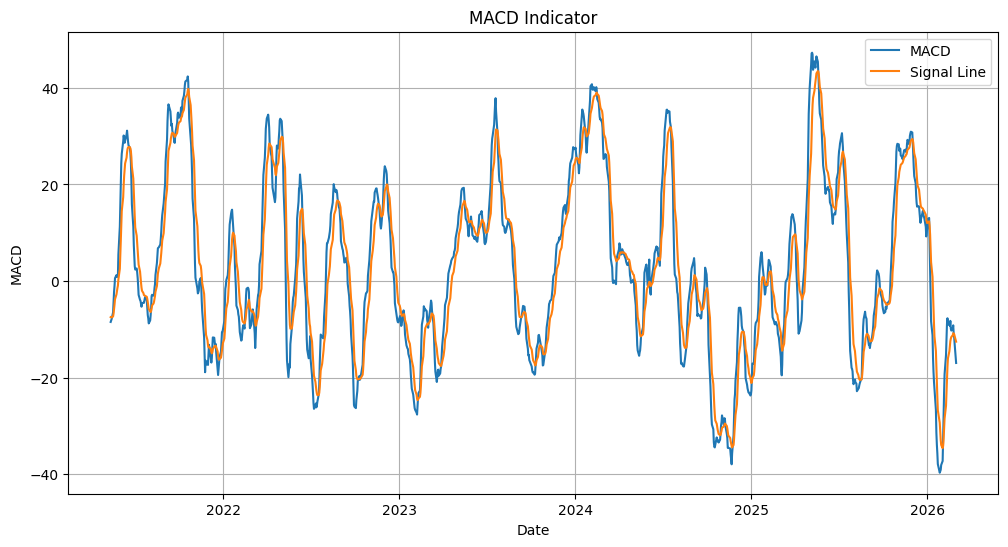

In [11]:
plt.figure(figsize=(12,6))

plt.plot(df.index, df["MACD"], label="MACD")
plt.plot(df.index, df["MACD_Signal"], label="Signal Line")

plt.title("MACD Indicator")
plt.xlabel("Date")
plt.ylabel("MACD")
plt.legend()
plt.grid(True)
plt.show()

## MACD Interpretation

- When MACD crosses above the Signal Line → Bullish momentum.
- When MACD crosses below the Signal Line → Bearish momentum.
- MACD helps capture trend strength and reversals.

This makes it a strong feature for trend classification models.

In [12]:
# Simple Moving Averages
df["SMA_20"] = df["Close"].rolling(window=20).mean()
df["SMA_50"] = df["Close"].rolling(window=50).mean()
df["SMA_200"] = df["Close"].rolling(window=200).mean()

df[["Close", "SMA_20", "SMA_50", "SMA_200"]].head(25)

,Close,SMA_20,SMA_50,SMA_200
Price,,,,
2021-05-12,867.481934,NaN,NaN,NaN
2021-05-14,878.432373,NaN,NaN,NaN
2021-05-17,888.883911,NaN,NaN,NaN
2021-05-18,901.398682,NaN,NaN,NaN
2021-05-19,905.524841,NaN,NaN,NaN
2021-05-20,900.242371,NaN,NaN,NaN
2021-05-21,908.018738,NaN,NaN,NaN
2021-05-24,900.355774,NaN,NaN,NaN
2021-05-25,890.153625,NaN,NaN,NaN


In [13]:
df = df.dropna()
df.head()

,Close,High,Low,Open,Volume,RSI,MACD,MACD_Signal,MACD_Hist,SMA_20,SMA_50,SMA_200
Price,,,,,,,,,,,,
2022-02-25,1039.224731,1050.144952,1035.721099,1037.472855,14570089,37.850397,-9.748898,-5.561144,-4.187753,1078.082758,1091.734470,1058.394855
2022-02-28,1073.623535,1077.172661,1020.591970,1020.591970,21297446,47.757654,-8.982088,-6.245333,-2.736755,1077.467346,1091.908284,1059.425563
2022-03-02,1091.369141,1092.483982,1059.814064,1062.202855,21471786,52.007926,-6.863347,-6.368936,-0.494411,1077.918945,1093.011233,1060.490247
2022-03-03,1082.155151,1098.785820,1078.401303,1092.028893,10186748,49.744926,-5.860169,-6.267182,0.407014,1077.799512,1093.621406,1061.456603
2022-03-04,1058.153198,1075.784852,1055.787154,1070.643199,10805667,44.333292,-6.922106,-6.398167,-0.523939,1077.180695,1093.252393,1062.240376


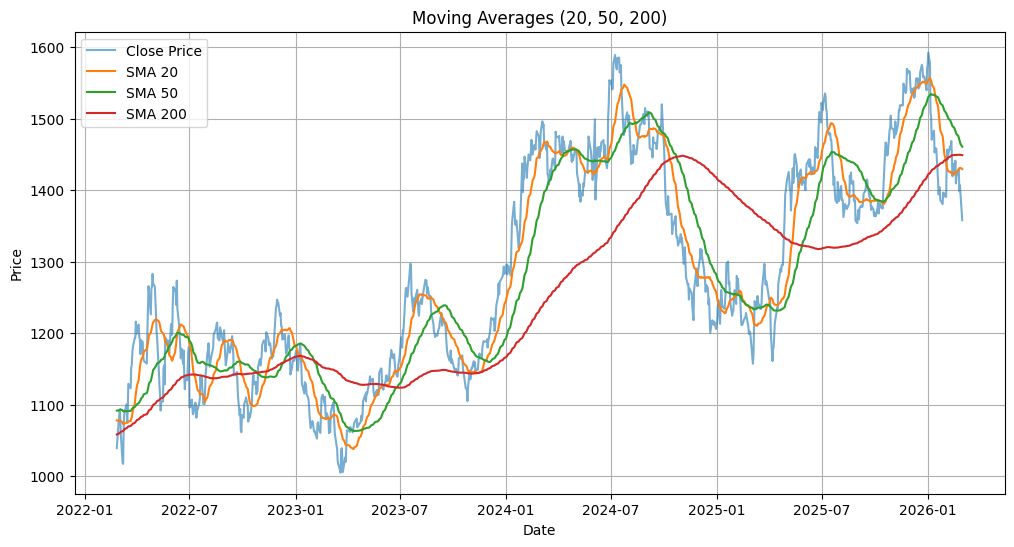

In [14]:
plt.figure(figsize=(12,6))

plt.plot(df.index, df["Close"], label="Close Price", alpha=0.6)
plt.plot(df.index, df["SMA_20"], label="SMA 20")
plt.plot(df.index, df["SMA_50"], label="SMA 50")
plt.plot(df.index, df["SMA_200"], label="SMA 200")

plt.title("Moving Averages (20, 50, 200)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

## Moving Average Interpretation

- SMA 20 captures short-term momentum.
- SMA 50 captures medium-term trend.
- SMA 200 represents long-term market direction.

Crossovers between moving averages can signal trend reversals.
These features are widely used in quantitative trading systems.

In [15]:
# 20-day average volume
df["Volume_MA20"] = df["Volume"].rolling(window=20).mean()

In [16]:
df["Volume_Ratio"] = df["Volume"] / df["Volume_MA20"]

df[["Volume", "Volume_MA20", "Volume_Ratio"]].head()

,Volume,Volume_MA20,Volume_Ratio
Price,,,
2022-02-25,14570089,NaN,NaN
2022-02-28,21297446,NaN,NaN
2022-03-02,21471786,NaN,NaN
2022-03-03,10186748,NaN,NaN
2022-03-04,10805667,NaN,NaN


In [17]:
df = df.dropna()

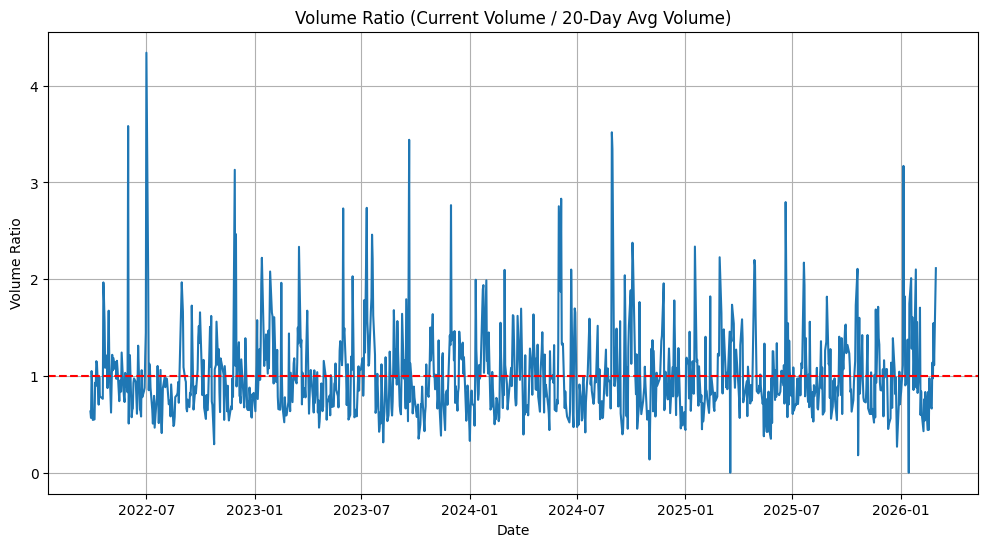

In [18]:
plt.figure(figsize=(12,6))
plt.plot(df.index, df["Volume_Ratio"])
plt.axhline(1, color="red", linestyle="--")
plt.title("Volume Ratio (Current Volume / 20-Day Avg Volume)")
plt.xlabel("Date")
plt.ylabel("Volume Ratio")
plt.grid(True)
plt.show()

## Volume Ratio Interpretation

- Volume Ratio > 1 indicates higher-than-average trading activity.
- High volume during price increases strengthens bullish signals.
- High volume during price declines strengthens bearish signals.

Volume enhances price-based indicators and improves model robustness.

In [19]:
# Compute 5-day future return
df["Future_Return_5D"] = df["Close"].shift(-5) / df["Close"] - 1

df[["Close", "Future_Return_5D"]].head()

,Close,Future_Return_5D
Price,,
2022-03-28,1193.018799,0.015923
2022-03-29,1193.291870,0.001334
2022-03-30,1216.224609,-0.020165
2022-03-31,1198.842896,-0.023494
2022-04-01,1208.443726,-0.015136


In [20]:
def classify_trend(x):
    if x > 0.02:
        return 1      # Uptrend
    elif x < -0.02:
        return -1     # Downtrend
    else:
        return 0      # Stable

df["Target"] = df["Future_Return_5D"].apply(classify_trend)

df[["Future_Return_5D", "Target"]].head()

,Future_Return_5D,Target
Price,,
2022-03-28,0.015923,0
2022-03-29,0.001334,0
2022-03-30,-0.020165,-1
2022-03-31,-0.023494,-1
2022-04-01,-0.015136,0


In [21]:
df = df.dropna()

df.tail()

,Close,High,Low,Open,Volume,RSI,MACD,MACD_Signal,MACD_Hist,SMA_20,SMA_50,SMA_200,Volume_MA20,Volume_Ratio,Future_Return_5D,Target
Price,,,,,,,,,,,,,,,,
2026-02-17,1423.000000,1431.800049,1418.599976,1431.099976,10731630,43.715136,-9.266460,-13.467085,4.200625,1422.334998,1485.160000,1449.219872,12840778.80,0.835746,0.004076,0
2026-02-18,1441.300049,1442.099976,1419.199951,1427.000000,5521096,48.613504,-8.231688,-12.420006,4.188318,1424.700000,1483.126001,1449.298340,12457358.70,0.443200,-0.029695,-1
2026-02-19,1409.500000,1443.000000,1400.000000,1443.000000,11884664,41.805047,-9.863916,-11.908788,2.044871,1424.945001,1480.728000,1449.269602,12183955.90,0.975436,-0.001916,0
2026-02-20,1419.400024,1427.400024,1406.099976,1409.500000,8177670,44.415057,-10.240573,-11.575145,1.334572,1425.790002,1478.378000,1449.364568,11806754.75,0.692626,-0.017965,0
2026-02-23,1428.000000,1434.900024,1418.300049,1425.000000,7758856,46.653313,-9.732935,-11.206703,1.473768,1427.885004,1476.038000,1449.497553,11702807.45,0.662991,-0.049020,-1


In [22]:
df["Target"].value_counts()

Target
 0    506
 1    240
-1    222
Name: count, dtype: int64

In [24]:
df.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume', 'RSI', 'MACD', 'MACD_Signal',
       'MACD_Hist', 'SMA_20', 'SMA_50', 'SMA_200', 'Volume_MA20',
       'Volume_Ratio', 'Future_Return_5D', 'Target'],
      dtype='object')

In [25]:
# Recreate Daily Return
df["Daily_Return"] = df["Close"].pct_change()

# Recreate Rolling Volatility (20-day)
df["Rolling_Volatility"] = df["Daily_Return"].rolling(20).std()

# Drop NaNs created by rolling calculations
df = df.dropna()

df.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume', 'RSI', 'MACD', 'MACD_Signal',
       'MACD_Hist', 'SMA_20', 'SMA_50', 'SMA_200', 'Volume_MA20',
       'Volume_Ratio', 'Future_Return_5D', 'Target', 'Daily_Return',
       'Rolling_Volatility'],
      dtype='object')

In [26]:
selected_columns = [
    "Close",
    "Daily_Return",
    "Rolling_Volatility",
    "RSI",
    "MACD",
    "MACD_Signal",
    "MACD_Hist",
    "SMA_20",
    "SMA_50",
    "SMA_200",
    "Volume_Ratio",
    "Target"
]

df_model = df[selected_columns]

df_model.head()

,Close,Daily_Return,Rolling_Volatility,RSI,MACD,MACD_Signal,MACD_Hist,SMA_20,SMA_50,SMA_200,Volume_Ratio,Target
Price,,,,,,,,,,,,
2022-04-27,1264.182617,0.000973,0.017776,65.155013,31.005087,26.590278,4.414809,1208.040997,1140.257859,1096.517330,1.338175,-1
2022-04-28,1283.065796,0.014937,0.017956,67.746673,33.279303,27.928083,5.351221,1212.529694,1144.293364,1098.132168,1.674317,-1
2022-04-29,1269.597290,-0.010497,0.017841,64.085450,33.607435,29.063953,4.543482,1215.198328,1148.403940,1099.719364,1.181372,-1
2022-05-02,1265.138062,-0.003512,0.017473,62.873922,33.125806,29.876324,3.249482,1218.513086,1151.702773,1101.332950,0.621580,-1
2022-05-04,1225.643066,-0.031218,0.018997,53.268589,29.220361,29.745131,-0.524770,1219.373053,1154.257209,1102.719712,1.218453,-1


In [27]:
df_model.head()

,Close,Daily_Return,Rolling_Volatility,RSI,MACD,MACD_Signal,MACD_Hist,SMA_20,SMA_50,SMA_200,Volume_Ratio,Target
Price,,,,,,,,,,,,
2022-04-27,1264.182617,0.000973,0.017776,65.155013,31.005087,26.590278,4.414809,1208.040997,1140.257859,1096.517330,1.338175,-1
2022-04-28,1283.065796,0.014937,0.017956,67.746673,33.279303,27.928083,5.351221,1212.529694,1144.293364,1098.132168,1.674317,-1
2022-04-29,1269.597290,-0.010497,0.017841,64.085450,33.607435,29.063953,4.543482,1215.198328,1148.403940,1099.719364,1.181372,-1
2022-05-02,1265.138062,-0.003512,0.017473,62.873922,33.125806,29.876324,3.249482,1218.513086,1151.702773,1101.332950,0.621580,-1
2022-05-04,1225.643066,-0.031218,0.018997,53.268589,29.220361,29.745131,-0.524770,1219.373053,1154.257209,1102.719712,1.218453,-1


In [28]:
df_model.to_csv("../data/processed/reliance_processed.csv")

print("Processed dataset saved successfully ✅")

Processed dataset saved successfully ✅
